In [1]:
import os 
import numpy as np 
from pathlib import Path 

import torch 
import torch.nn as nn 
import torch.nn.functional as F

from torch.utils.data import Dataset 
from torch.utils.data import DataLoader 

from tqdm import tqdm

import matplotlib.pyplot as plt 


In [2]:
print(torch.__version__)

2.12.0+cu126


In [ ]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

BATCH_SIZE = 8 
LEARNING_RATE = 1e-4
NUM_EPOCHS = 150
CHECKPOINT_DIR = Path(
    "../checkpoints"
)

CHECKPOINT_DIR.mkdir(
    exist_ok=True
)

BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_sam_head.pth"
)

print(DEVICE)

cuda


In [6]:
PROJECT_ROOT = Path("../")

TRAIN_MASK_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/train/masks"
)

TRAIN_SAM_DIR = (
    PROJECT_ROOT /
    "dataset/sam_embeddings/strum_rgb_vit_b/train"
)

VAL_MASK_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/val/masks"
)

VAL_SAM_DIR = (
    PROJECT_ROOT /
    "dataset/sam_embeddings/strum_rgb_vit_b/val"
)

TEST_MASK_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/test/masks"
)

TEST_SAM_DIR = (
    PROJECT_ROOT /
    "dataset/sam_embeddings/strum_rgb_vit_b/test"
)

In [7]:
train_embeddings = sorted(
    TRAIN_SAM_DIR.glob("*.npy")
)

train_masks = sorted(
    TRAIN_MASK_DIR.glob("*.npy")
)

val_embeddings = sorted(
    VAL_SAM_DIR.glob("*.npy")
)

val_masks = sorted(
    VAL_MASK_DIR.glob("*.npy")
)

test_embeddings = sorted(
    TEST_SAM_DIR.glob("*.npy")
)

test_masks = sorted(
    TEST_MASK_DIR.glob("*.npy")
)

In [8]:
print(
    len(train_embeddings),
    len(train_masks)
)

print(
    len(val_embeddings),
    len(val_masks)
)

print(
    len(test_embeddings),
    len(test_masks)
)

2140 2140
267 267
268 268


In [9]:
sample_embedding = np.load(
    train_embeddings[0]
)

print(
    sample_embedding.shape
)

print(
    sample_embedding.dtype
)

(256, 64, 64)
float16


In [10]:
class SAMDataset(Dataset):

    def __init__(
        self,
        embeddings,
        masks
    ):

        self.embeddings = embeddings
        self.masks = masks

    def __len__(self):

        return len(
            self.embeddings
        )

    def __getitem__(
        self,
        idx
    ):

        embedding = np.load(
            self.embeddings[idx]
        )

        mask = np.load(
            self.masks[idx]
        )

        embedding = torch.tensor(
            embedding,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )

        if mask.ndim == 2:

            mask = mask.unsqueeze(0)

        return (
            embedding,
            mask
        )

In [12]:
dataset = SAMDataset(
    train_embeddings,
    train_masks
)

embedding, mask = dataset[0]

print(
    embedding.shape
)

print(
    mask.shape
)

print(
    embedding.dtype
)

print(
    mask.dtype
)

torch.Size([256, 64, 64])
torch.Size([1, 128, 128])
torch.float32
torch.float32


In [13]:
print(
    embedding.min().item(),
    embedding.max().item()
)

print(
    mask.min().item(),
    mask.max().item()
)

-0.857421875 0.80810546875
0.0 1.0


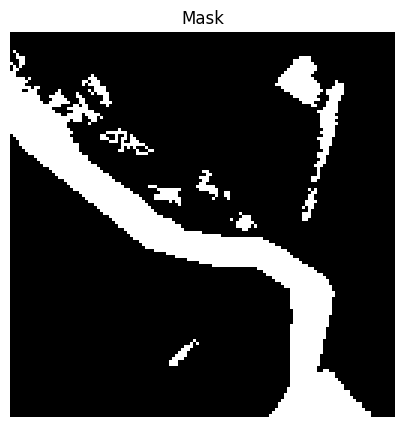

In [14]:
plt.figure(figsize=(5,5))

plt.imshow(
    mask.squeeze(),
    cmap="gray"
)

plt.title(
    "Mask"
)

plt.axis("off")

plt.show()

In [15]:
train_dataset = SAMDataset(
    train_embeddings,
    train_masks
)

val_dataset = SAMDataset(
    val_embeddings,
    val_masks
)

test_dataset = SAMDataset(
    test_embeddings,
    test_masks
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [16]:
print(
    len(train_loader)
)

print(
    len(val_loader)
)

print(
    len(test_loader)
)

268
34
34


In [17]:
embeddings, masks = next(
    iter(train_loader)
)

print(
    embeddings.shape
)

print(
    masks.shape
)

torch.Size([8, 256, 64, 64])
torch.Size([8, 1, 128, 128])


In [18]:
print(
    embeddings.dtype
)

print(
    masks.dtype
)

torch.float32
torch.float32


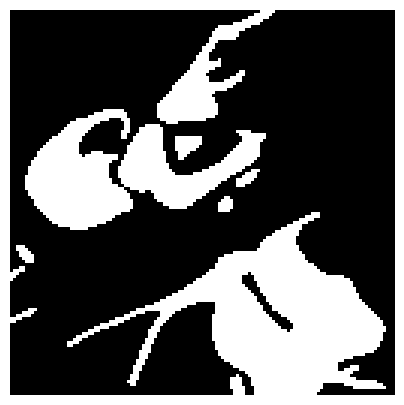

In [19]:
plt.figure(figsize=(5,5))

plt.imshow(
    masks[0].squeeze(),
    cmap="gray"
)

plt.axis("off")

plt.show()

In [20]:
class SAMSegmentationHead(nn.Module):

    def __init__(self):

        super().__init__()

        self.decoder = nn.Sequential(

            nn.Conv2d(
                256,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                128
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                128,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                64
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                64,
                1,
                kernel_size=1
            )
        )

    def forward(
        self,
        embedding
    ):

        x = self.decoder(
            embedding
        )

        x = F.interpolate(
            x,
            size=(128, 128),
            mode="bilinear",
            align_corners=False
        )

        return x

In [21]:
model = SAMSegmentationHead()

print(model)

SAMSegmentationHead(
  (decoder): Sequential(
    (0): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
  )
)


In [22]:
dummy_embedding = torch.randn(
    2,
    256,
    64,
    64
)

with torch.no_grad():

    output = model(
        dummy_embedding
    )

print(
    output.shape
)

torch.Size([2, 1, 128, 128])


In [23]:
num_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)

print(
    f"{num_params:,}"
)

369,281


In [24]:
model = SAMSegmentationHead().to(
    DEVICE
)

dummy_embedding = torch.randn(
    2,
    256,
    64,
    64
).to(DEVICE)

with torch.no_grad():

    output = model(
        dummy_embedding
    )

print(
    output.shape
)

torch.Size([2, 1, 128, 128])


In [25]:
class DiceLoss(nn.Module):

    def __init__(
        self,
        smooth=1e-6
    ):

        super().__init__()

        self.smooth = smooth

    def forward(
        self,
        logits,
        targets
    ):

        probs = torch.sigmoid(
            logits
        )

        probs = probs.view(-1)

        targets = targets.view(-1)

        intersection = (
            probs * targets
        ).sum()

        dice = (
            2.0 * intersection +
            self.smooth
        ) / (
            probs.sum() +
            targets.sum() +
            self.smooth
        )

        return 1.0 - dice

In [26]:
dice_loss = DiceLoss()

pred = torch.randn(
    2,
    1,
    128,
    128
)

target = torch.randint(
    0,
    2,
    (
        2,
        1,
        128,
        128
    )
).float()

print(
    dice_loss(
        pred,
        target
    )
)

tensor(0.4980)


In [27]:
bce_loss = nn.BCEWithLogitsLoss()

dice_loss = DiceLoss()

In [28]:
def segmentation_loss(
    outputs,
    masks
):

    bce = bce_loss(
        outputs,
        masks
    )

    dice = dice_loss(
        outputs,
        masks
    )

    return (
        bce + dice
    )

In [30]:
outputs = torch.randn(
    2,
    1,
    128,
    128
)

masks = torch.randint(
    0,
    2,
    (
        2,
        1,
        128,
        128
    )
).float()

print(
    segmentation_loss(
        outputs,
        masks
    )
)

tensor(1.3059)


In [31]:
model = SAMSegmentationHead().to(
    DEVICE
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

In [32]:
print(
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

369281


In [41]:
import torch


def pixel_accuracy(outputs, masks):

    probs = torch.sigmoid(outputs)

    preds = (probs > 0.5).float()

    correct = (preds == masks).float().sum()

    total = masks.numel()

    return (correct / total).item()


def precision_score(outputs, masks):

    probs = torch.sigmoid(outputs)

    preds = (probs > 0.5).float()

    tp = ((preds == 1) & (masks == 1)).sum().float()

    fp = ((preds == 1) & (masks == 0)).sum().float()

    precision = tp / (tp + fp + 1e-6)

    return precision.item()


def recall_score(outputs, masks):

    probs = torch.sigmoid(outputs)

    preds = (probs > 0.5).float()

    tp = ((preds == 1) & (masks == 1)).sum().float()

    fn = ((preds == 0) & (masks == 1)).sum().float()

    recall = tp / (tp + fn + 1e-6)

    return recall.item()


def dice_score(outputs, masks):

    probs = torch.sigmoid(outputs)

    preds = (probs > 0.5).float()

    intersection = (preds * masks).sum()

    dice = (
        2.0 * intersection + 1e-6
    ) / (
        preds.sum() +
        masks.sum() +
        1e-6
    )

    return dice.item()


def iou_score(outputs, masks):

    probs = torch.sigmoid(outputs)

    preds = (probs > 0.5).float()

    intersection = (
        preds * masks
    ).sum()

    union = (
        preds.sum() +
        masks.sum() -
        intersection
    )

    iou = (
        intersection + 1e-6
    ) / (
        union + 1e-6
    )

    return iou.item()

In [42]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    running_acc = 0.0
    running_precision = 0.0
    running_recall = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for embeddings, masks in tqdm(loader):

        embeddings = embeddings.to(device)

        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(
            embeddings
        )

        loss = segmentation_loss(
            outputs,
            masks
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        running_acc += pixel_accuracy(
            outputs,
            masks
        )

        running_precision += precision_score(
            outputs,
            masks
        )

        running_recall += recall_score(
            outputs,
            masks
        )

        running_dice += dice_score(
            outputs,
            masks
        )

        running_iou += iou_score(
            outputs,
            masks
        )

    num_batches = len(loader)

    return {

        "loss":
            running_loss / num_batches,

        "acc":
            running_acc / num_batches,

        "precision":
            running_precision / num_batches,

        "recall":
            running_recall / num_batches,

        "dice":
            running_dice / num_batches,

        "iou":
            running_iou / num_batches
    }

In [43]:
@torch.no_grad()

def validate_one_epoch(
    model,
    loader,
    device
):

    model.eval()

    running_loss = 0.0

    running_acc = 0.0
    running_precision = 0.0
    running_recall = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for embeddings, masks in loader:

        embeddings = embeddings.to(device)

        masks = masks.to(device)

        outputs = model(
            embeddings
        )

        loss = segmentation_loss(
            outputs,
            masks
        )

        running_loss += loss.item()

        running_acc += pixel_accuracy(
            outputs,
            masks
        )

        running_precision += precision_score(
            outputs,
            masks
        )

        running_recall += recall_score(
            outputs,
            masks
        )

        running_dice += dice_score(
            outputs,
            masks
        )

        running_iou += iou_score(
            outputs,
            masks
        )

    num_batches = len(loader)

    return {

        "loss":
            running_loss / num_batches,

        "acc":
            running_acc / num_batches,

        "precision":
            running_precision / num_batches,

        "recall":
            running_recall / num_batches,

        "dice":
            running_dice / num_batches,

        "iou":
            running_iou / num_batches
    }

In [44]:
embeddings, masks = next(
    iter(train_loader)
)

embeddings = embeddings.to(
    DEVICE
)

masks = masks.to(
    DEVICE
)

with torch.no_grad():

    outputs = model(
        embeddings
    )

print(
    outputs.shape
)

print(
    masks.shape
)

print(
    segmentation_loss(
        outputs,
        masks
    )
)

torch.Size([8, 1, 128, 128])
torch.Size([8, 1, 128, 128])
tensor(1.4394, device='cuda:0')


In [45]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

In [46]:
history = {

    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_dice": [],
    "val_dice": [],

    "train_iou": [],
    "val_iou": []
}

In [47]:
outputs.shape

torch.Size([8, 1, 128, 128])

In [48]:
best_val_iou = 0.0

for epoch in range(NUM_EPOCHS):

    train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        DEVICE
    )

    val_metrics = validate_one_epoch(
        model,
        val_loader,
        DEVICE
    )

    scheduler.step(
        val_metrics["loss"]
    )

    history["train_loss"].append(
        train_metrics["loss"]
    )

    history["val_loss"].append(
        val_metrics["loss"]
    )

    history["train_acc"].append(
        train_metrics["acc"]
    )

    history["val_acc"].append(
        val_metrics["acc"]
    )

    history["train_precision"].append(
        train_metrics["precision"]
    )

    history["val_precision"].append(
        val_metrics["precision"]
    )

    history["train_recall"].append(
        train_metrics["recall"]
    )

    history["val_recall"].append(
        val_metrics["recall"]
    )

    history["train_dice"].append(
        train_metrics["dice"]
    )

    history["val_dice"].append(
        val_metrics["dice"]
    )

    history["train_iou"].append(
        train_metrics["iou"]
    )

    history["val_iou"].append(
        val_metrics["iou"]
    )

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val IoU: {val_metrics['iou']:.4f}"
    )

    if val_metrics["iou"] > best_val_iou:

        best_val_iou = val_metrics["iou"]

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            f"Best Model Saved | "
            f"IoU: {best_val_iou:.4f}"
        )

100%|██████████| 268/268 [02:06<00:00,  2.11it/s]


Epoch [1/100] | Train Loss: 1.2895 | Val Loss: 1.3109 | Val IoU: 0.1930
Best Model Saved | IoU: 0.1930


100%|██████████| 268/268 [00:31<00:00,  8.59it/s]


Epoch [2/100] | Train Loss: 1.2265 | Val Loss: 1.6357 | Val IoU: 0.2596
Best Model Saved | IoU: 0.2596


100%|██████████| 268/268 [00:20<00:00, 13.01it/s]


...

Epoch [98/100] | Train Loss: 1.0646 | Val Loss: 1.1065 | Val IoU: 0.2817


100%|██████████| 268/268 [00:19<00:00, 13.65it/s]


Epoch [99/100] | Train Loss: 1.0577 | Val Loss: 1.1081 | Val IoU: 0.2953


100%|██████████| 268/268 [00:19<00:00, 13.76it/s]


Epoch [100/100] | Train Loss: 1.0590 | Val Loss: 1.1062 | Val IoU: 0.2918


In [49]:
print(
    BEST_MODEL_PATH
)

print(
    BEST_MODEL_PATH.exists()
)

..\checkpoints\best_sam_head.pth
True


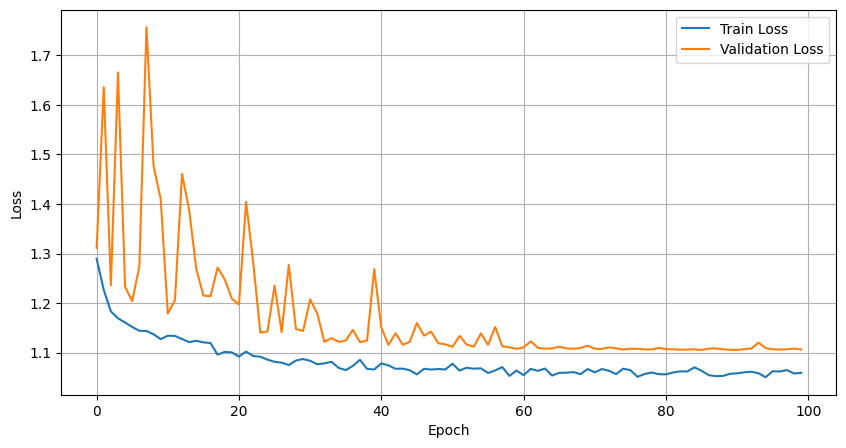

In [50]:
plt.figure(figsize=(10,5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

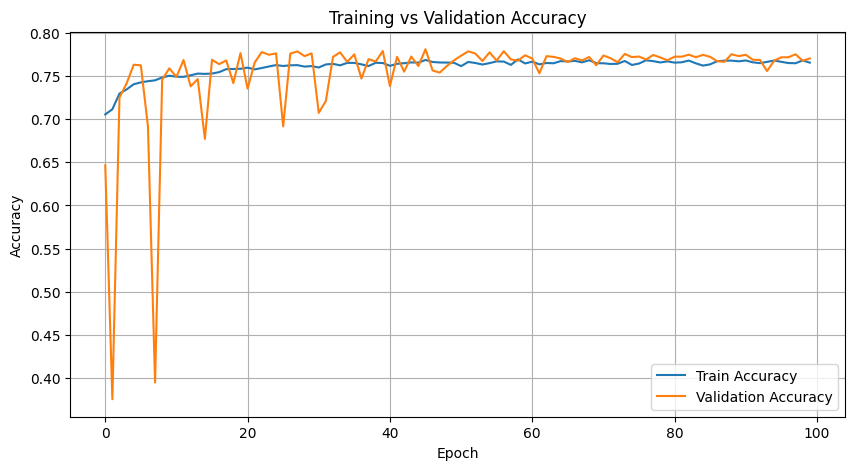

In [56]:
plt.figure(figsize=(10,5))

plt.plot(
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid()

plt.show()

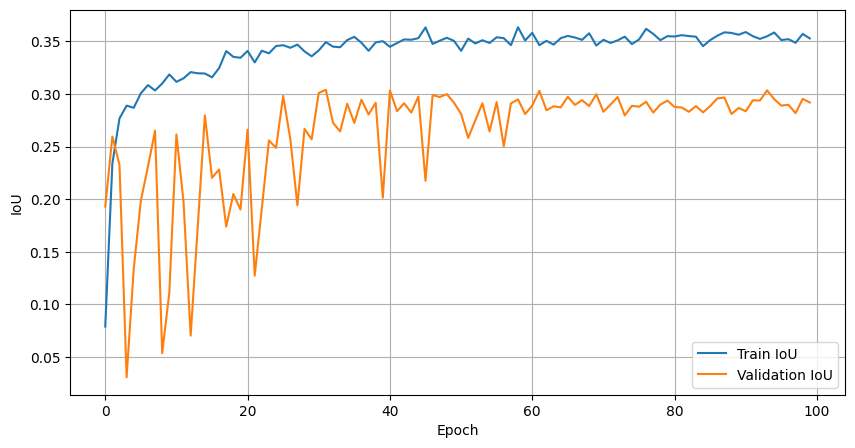

In [51]:
plt.figure(figsize=(10,5))

plt.plot(
    history["train_iou"],
    label="Train IoU"
)

plt.plot(
    history["val_iou"],
    label="Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("IoU")

plt.legend()

plt.grid()

plt.show()

In [52]:
best_model = SAMSegmentationHead().to(
    DEVICE
)

best_model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)

best_model.eval()

print(
    "Best model loaded."
)

Best model loaded.


In [53]:
print(
    best_val_iou
)

0.30389237883911635


In [54]:
@torch.no_grad()

def evaluate_model(
    model,
    loader,
    device
):

    model.eval()

    running_acc = 0.0
    running_precision = 0.0
    running_recall = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for embeddings, masks in loader:

        embeddings = embeddings.to(device)

        masks = masks.to(device)

        outputs = model(
            embeddings
        )

        running_acc += pixel_accuracy(
            outputs,
            masks
        )

        running_precision += precision_score(
            outputs,
            masks
        )

        running_recall += recall_score(
            outputs,
            masks
        )

        running_dice += dice_score(
            outputs,
            masks
        )

        running_iou += iou_score(
            outputs,
            masks
        )

    n = len(loader)

    return {

        "acc":
            running_acc / n,

        "precision":
            running_precision / n,

        "recall":
            running_recall / n,

        "dice":
            running_dice / n,

        "iou":
            running_iou / n
    }

In [55]:
@torch.no_grad()

def evaluate_model(
    model,
    loader,
    device
):

    model.eval()

    running_acc = 0.0
    running_precision = 0.0
    running_recall = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for embeddings, masks in loader:

        embeddings = embeddings.to(device)

        masks = masks.to(device)

        outputs = model(
            embeddings
        )

        running_acc += pixel_accuracy(
            outputs,
            masks
        )

        running_precision += precision_score(
            outputs,
            masks
        )

        running_recall += recall_score(
            outputs,
            masks
        )

        running_dice += dice_score(
            outputs,
            masks
        )

        running_iou += iou_score(
            outputs,
            masks
        )

    n = len(loader)

    return {

        "acc":
            running_acc / n,

        "precision":
            running_precision / n,

        "recall":
            running_recall / n,

        "dice":
            running_dice / n,

        "iou":
            running_iou / n
    }